# Training Gaussian Splats

The `Splatter` wrapper provides a high-level interface over [nerfstudio](https://docs.nerf.studio/) for training Gaussian splat models from video. It handles the full COLMAP-based preprocessing pipeline, rade-features training, and optional mesh export — with each stage individually configurable. This notebook walks through the three-step pipeline: preprocess → extract features (train) → visualize.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

import pyvista as pv
%matplotlib inline

pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

from collab_splats.wrapper import Splatter, SplatterConfig
from collab_splats.utils.visualization import visualize_splat

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/mobile_sam/mod

/workspace/nerfstudio/nerfstudio/field_components/activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
/workspace/nerfstudio/nerfstudio/field_components/activations.py:38: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATASET     = "birds_c0043"
BASE_DIR    = Path("/workspace/fieldwork-data/")
SESSION_DIR = BASE_DIR / "birds/2024-02-06/SplatsSD"
VIDEO_PATH  = SESSION_DIR / "C0043.MP4"

CACHE = Path("../../.cache") / DATASET

## §1 — Splatter setup

Initialize `SplatterConfig` with the video path and desired nerfstudio method. Call `available_methods()` to see all supported backends.

In [4]:
Splatter.available_methods()

Available methods:
   ['feature-splatting', 'rade-features', 'rade-gs', 'splatfacto']


Build the `SplatterConfig` and instantiate `Splatter`. The wrapper validates the config and resolves output paths automatically.

In [5]:
# Make the configuration
splatter_config = SplatterConfig(
    file_path=VIDEO_PATH,
    method="rade-features",
    frame_proportion=0.25,  # Use 25% of the frames within the video (or default to minimum 300 frames)
)

# Initialize the Splatter class
splatter = Splatter(splatter_config)

## §2 — Preprocess

Run COLMAP to extract camera poses and sparse point cloud. This is the most time-consuming step and scales with the number of extracted frames. Skipped automatically if `transforms.json` already exists.

In [6]:
# Skip if preprocessing already completed (transforms.json exists)
if not (splatter.config.get("preproc_data_path") and
        (Path(splatter.config["preproc_data_path"]) / "transforms.json").exists()):
    # Calls ns-process-data → COLMAP; scales with frame count
    splatter.preprocess()
else:
    print("Preprocessing already done — loading existing.")

transforms.json already exists at /workspace/fieldwork-data/birds/2024-02-06/environment/C0043/preproc/transforms.json
To rerun preprocessing, set overwrite=True


## §3 — Train (extract features)

Train the rade-features model via `ns-train`. Skipped if a trained run already exists in the output directory.

In [7]:
# Skip if model already trained (config.yml exists in output dir)
output_dir = Path(splatter.config.get("output_path", "")) / "rade-features"
trained_configs = list(output_dir.glob("*/config.yml")) if output_dir.exists() else []
if not trained_configs:
    # Trains the splatting model; quits viewer on completion automatically
    splatter.extract_features()
else:
    print("Model already trained — loading existing.")
    splatter._select_run()

Model already trained — loading existing.

Available runs:
[0] 2026-04-29_021745


## §4 — Visualize

`viewer()` opens an interactive nerfstudio web viewer — run manually for exploration. In headless/notebook mode, render a static screenshot of the reconstructed mesh via PyVista instead.

2026-05-23 08:27:57.807 (  34.620s) [    79F6FC8A7740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


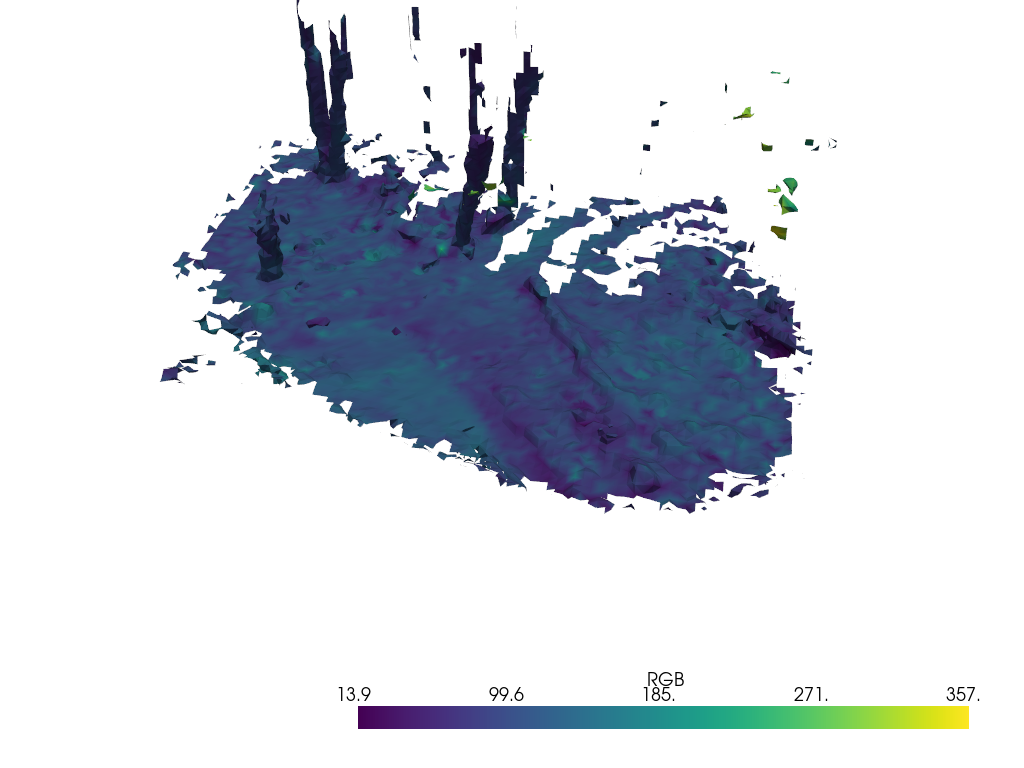

In [8]:
# viewer() opens an interactive nerfstudio web viewer — run manually for exploration.
# In headless mode, render a static screenshot via PyVista instead.

# Resolve mesh path: use mesh_info if already populated, otherwise derive from output_path
if splatter.config.get("mesh_info", {}).get("mesh"):
    mesh_fn = splatter.config["mesh_info"]["mesh"].as_posix()
else:
    # Standard output location after splatter.mesh() has been run
    mesh_fn = str(Path(splatter.config["output_path"]) / "rade-features" / "mesh" / "mesh_tsdf_clean.ply")

pl = visualize_splat(mesh=mesh_fn)
pl.show()